# QML Baseline

# QSCM Implemenation 

Train shape: (300, 13)
Test shape : (200, 13)
Train columns (head): ['PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC_5', 'PC_6', 'PC_7', 'PC_8', 'PC_9', 'PC_10']
Detected LABEL_COL: label
y_train distribution: [150 150]
y_test  distribution: [100 100]
n_features (qubits): 12

Computing quantum kernel matrices...


C:\Users\shanmugam\AppData\Local\Temp\ipykernel_2876\1045013425.py:101: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=n_features, reps=2, entanglement="linear")


K_train: (300, 300) K_test: (200, 300)

================ QSVM BASELINE RESULTS ================
Accuracy : 0.7900
Precision: 0.7042
Recall   : 1.0000
F1-score : 0.8264
ROC-AUC  : 0.9158
PR-AUC   : 0.8776

Confusion Matrix:
 [[ 58  42]
 [  0 100]]


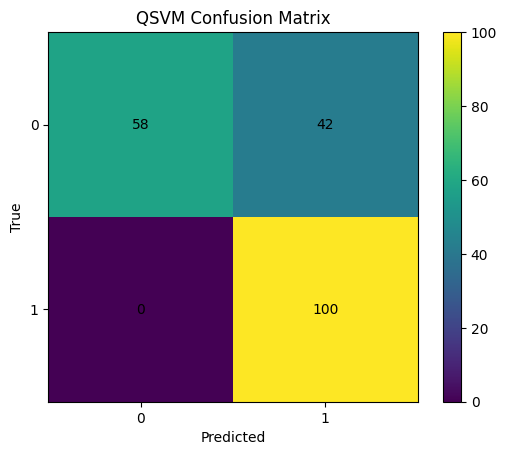

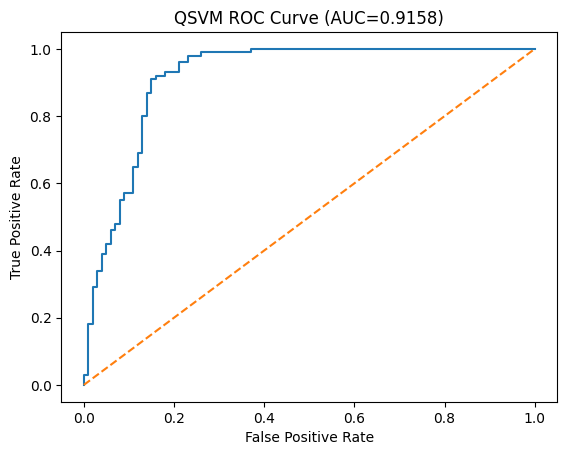

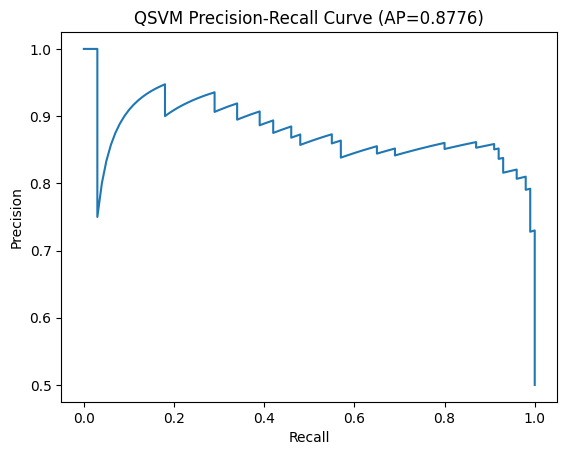

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)

from qiskit.circuit.library import ZZFeatureMap
from qiskit.quantum_info import Statevector

# ----------------------------
# Paths (your uploaded files)
# ----------------------------
TRAIN_PATH = "train_pca12.csv"
TEST_PATH  = "test_pca12.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("Train columns (head):", list(train_df.columns[:10]))

# ----------------------------
# Auto-detect label column
# ----------------------------
def detect_label_col(df):
    candidates = ["label", "Label", "y", "Y", "target", "Target", "class", "Class"]
    for c in candidates:
        if c in df.columns:
            return c
    # fallback: assume last column is label if it's binary-ish
    last = df.columns[-1]
    if df[last].nunique() <= 10:
        return last
    raise ValueError("Could not detect label column. Rename label column to 'label'.")

LABEL_COL = detect_label_col(train_df)
print("Detected LABEL_COL:", LABEL_COL)

# ----------------------------
# Split X/y
# ----------------------------
X_train = train_df.drop(columns=[LABEL_COL]).values.astype(float)
y_train = train_df[LABEL_COL].values

X_test  = test_df.drop(columns=[LABEL_COL]).values.astype(float)
y_test  = test_df[LABEL_COL].values

# ----------------------------
# Ensure labels are 0/1
# ----------------------------
def make_binary_01(y):
    y = np.array(y)
    uniq = np.unique(y)
    if set(uniq.tolist()) <= {0, 1}:
        return y.astype(int)
    # map smallest -> 0, largest -> 1 (binary)
    if len(uniq) == 2:
        m = {uniq[0]: 0, uniq[1]: 1}
        return np.array([m[v] for v in y], dtype=int)
    raise ValueError(f"Labels are not binary. Unique labels: {uniq}")

y_train = make_binary_01(y_train)
y_test  = make_binary_01(y_test)

print("y_train distribution:", np.bincount(y_train))
print("y_test  distribution:", np.bincount(y_test))

# ----------------------------
# Standardize features
# ----------------------------
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# ----------------------------
# Quantum kernel (Statevector fidelity)
# ----------------------------
# NOTE:
# - QSVM becomes slow if n_qubits (= n_features) is large.
# - For PCA-12, using 12 qubits is heavy but doable for baseline if dataset is not huge.
# - If too slow, reduce qubits by selecting fewer PCA dims (e.g., PCA-4/8).
n_features = X_train_s.shape[1]
print("n_features (qubits):", n_features)

feature_map = ZZFeatureMap(feature_dimension=n_features, reps=2, entanglement="linear")

def statevec_from_x(x):
    qc = feature_map.assign_parameters(x)
    return Statevector.from_instruction(qc)

def fidelity(sv1, sv2):
    # |<ψ|φ>|^2
    return np.abs(np.vdot(sv1.data, sv2.data))**2

def compute_kernel_matrix(XA, XB, cache_sv=True):
    # returns K of shape (len(XA), len(XB))
    XA = np.asarray(XA)
    XB = np.asarray(XB)

    if cache_sv:
        svA = [statevec_from_x(x) for x in XA]
        svB = [statevec_from_x(x) for x in XB]
        K = np.empty((len(svA), len(svB)), dtype=float)
        for i, a in enumerate(svA):
            for j, b in enumerate(svB):
                K[i, j] = fidelity(a, b)
        return K
    else:
        K = np.empty((len(XA), len(XB)), dtype=float)
        for i, xa in enumerate(XA):
            sva = statevec_from_x(xa)
            for j, xb in enumerate(XB):
                svb = statevec_from_x(xb)
                K[i, j] = fidelity(sva, svb)
        return K

print("\nComputing quantum kernel matrices...")
K_train = compute_kernel_matrix(X_train_s, X_train_s, cache_sv=True)
K_test  = compute_kernel_matrix(X_test_s,  X_train_s, cache_sv=True)

print("K_train:", K_train.shape, "K_test:", K_test.shape)

# ----------------------------
# Train QSVM (SVC precomputed)
# ----------------------------
qsvm = SVC(kernel="precomputed", C=1.0, probability=True, class_weight="balanced", random_state=42)
qsvm.fit(K_train, y_train)

# Predictions
y_pred = qsvm.predict(K_test)
y_proba = qsvm.predict_proba(K_test)[:, 1]

# ----------------------------
# Metrics
# ----------------------------
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)

# AUCs (only valid if both classes exist in y_test)
roc_auc = roc_auc_score(y_test, y_proba) if len(np.unique(y_test)) == 2 else np.nan
pr_auc  = average_precision_score(y_test, y_proba) if len(np.unique(y_test)) == 2 else np.nan

print("\n================ QSVM BASELINE RESULTS ================")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# ----------------------------
# Plots: Confusion Matrix + ROC + PR
# ----------------------------
plt.figure()
plt.imshow(cm, interpolation="nearest")
plt.title("QSVM Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ["0","1"])
plt.yticks([0,1], ["0","1"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

if len(np.unique(y_test)) == 2:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0,1], [0,1], linestyle="--")
    plt.title(f"QSVM ROC Curve (AUC={roc_auc:.4f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()

    pr, rc, _ = precision_recall_curve(y_test, y_proba)
    plt.figure()
    plt.plot(rc, pr)
    plt.title(f"QSVM Precision-Recall Curve (AP={pr_auc:.4f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()

# VQC Implementation

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Using qiskit_aer.primitives.SamplerV2
Train shape: (300, 13)
Test shape : (200, 13)
Detected LABEL_COL: label
y_train distribution: [150 150]
y_test  distribution: [100 100]
n_features (qubits): 12

Training VQC...
Training done.

================ VQC RESULTS ================
Accuracy : 0.5500
Precision: 0.5521
Recall   : 0.5300
F1-score : 0.5408
ROC-AUC  : 0.5602
PR-AUC   : 0.5082

Confusion Matrix:
 [[57 43]
 [47 53]]


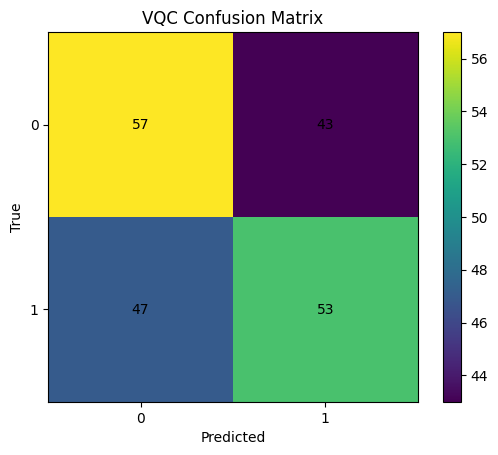

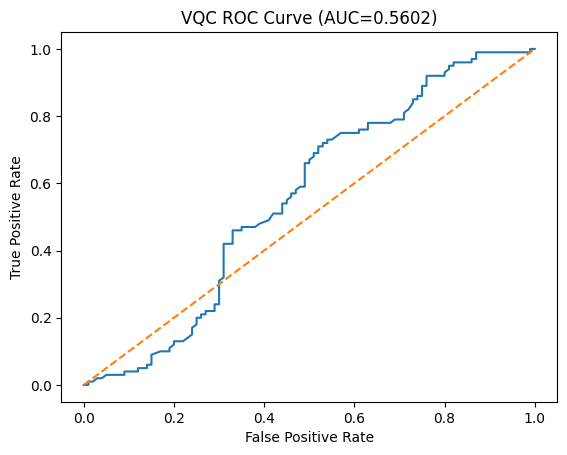

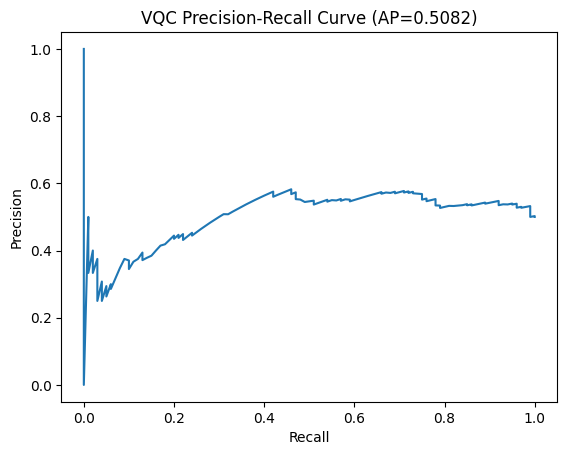

In [2]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)

from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_algorithms.optimizers import COBYLA
from qiskit_machine_learning.algorithms.classifiers import VQC

# ✅ Aer Sampler (works reliably in your stack)
from qiskit_aer.primitives import SamplerV2 as AerSampler
sampler = AerSampler()
print("Using qiskit_aer.primitives.SamplerV2")

# ----------------------------
# Load data
# ----------------------------
TRAIN_PATH = "train_pca12.csv"
TEST_PATH  = "test_pca12.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

# ----------------------------
# Detect label column
# ----------------------------
def detect_label_col(df):
    candidates = ["label", "Label", "y", "Y", "target", "Target", "class", "Class"]
    for c in candidates:
        if c in df.columns:
            return c
    last = df.columns[-1]
    if df[last].nunique() <= 10:
        return last
    raise ValueError("Could not detect label column. Rename label column to 'label'.")

LABEL_COL = detect_label_col(train_df)
print("Detected LABEL_COL:", LABEL_COL)

X_train = train_df.drop(columns=[LABEL_COL]).values.astype(float)
y_train = train_df[LABEL_COL].values
X_test  = test_df.drop(columns=[LABEL_COL]).values.astype(float)
y_test  = test_df[LABEL_COL].values

def make_binary_01(y):
    y = np.array(y)
    uniq = np.unique(y)
    if set(uniq.tolist()) <= {0, 1}:
        return y.astype(int)
    if len(uniq) == 2:
        m = {uniq[0]: 0, uniq[1]: 1}
        return np.array([m[v] for v in y], dtype=int)
    raise ValueError(f"Labels are not binary. Unique labels: {uniq}")

y_train = make_binary_01(y_train)
y_test  = make_binary_01(y_test)

print("y_train distribution:", np.bincount(y_train))
print("y_test  distribution:", np.bincount(y_test))

# ----------------------------
# Scale
# ----------------------------
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

n_features = X_train_s.shape[1]
print("n_features (qubits):", n_features)

# ----------------------------
# ✅ IMPORTANT FIX: decompose circuits
# ----------------------------
feature_map = ZZFeatureMap(feature_dimension=n_features, reps=1, entanglement="linear").decompose()
ansatz      = RealAmplitudes(num_qubits=n_features, reps=1, entanglement="linear").decompose()

# Optimizer (baseline)
optimizer = COBYLA(maxiter=80)

loss_history = []
def callback(weights, loss):
    loss_history.append(loss)

vqc = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=optimizer,
    sampler=sampler,
    callback=callback
)

print("\nTraining VQC...")
vqc.fit(X_train_s, y_train)
print("Training done.")

# ----------------------------
# Predict
# ----------------------------
y_pred = vqc.predict(X_test_s)

# predict_proba may not always be available; handle safely
y_proba = None
if hasattr(vqc, "predict_proba"):
    try:
        y_proba = vqc.predict_proba(X_test_s)[:, 1]
    except Exception:
        y_proba = None

# ----------------------------
# Metrics
# ----------------------------
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)

roc_auc = np.nan
pr_auc  = np.nan
if y_proba is not None and len(np.unique(y_test)) == 2:
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc  = average_precision_score(y_test, y_proba)

print("\n================ VQC RESULTS ================")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}" if not np.isnan(roc_auc) else "ROC-AUC  : (probabilities not available)")
print(f"PR-AUC   : {pr_auc:.4f}"  if not np.isnan(pr_auc)  else "PR-AUC   : (probabilities not available)")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# ----------------------------
# Plots
# ----------------------------
if len(loss_history) > 0:
    plt.figure()
    plt.plot(loss_history)
    plt.title("VQC Training Loss vs Iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.show()

plt.figure()
plt.imshow(cm, interpolation="nearest")
plt.title("VQC Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ["0","1"])
plt.yticks([0,1], ["0","1"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

if y_proba is not None and len(np.unique(y_test)) == 2:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0,1], [0,1], linestyle="--")
    plt.title(f"VQC ROC Curve (AUC={roc_auc:.4f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()

    pr, rc, _ = precision_recall_curve(y_test, y_proba)
    plt.figure()
    plt.plot(rc, pr)
    plt.title(f"VQC Precision-Recall Curve (AP={pr_auc:.4f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()

# QNN implementation

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train shape: (300, 13)
Test shape : (200, 13)
Detected LABEL_COL: label
y_train distribution: [150 150]
y_test  distribution : [100 100]
n_features (qubits): 12
Input params : 12
Weight params: 24
Circuit depth: 40  | size: 104
Using AerSamplerV2 with default_shots=1024

Training QNN...
Training done.

================ QNN RESULTS ================
Accuracy : 0.4750
Precision: 0.4725
Recall   : 0.4300
F1-score : 0.4503
ROC-AUC  : 0.4832
PR-AUC   : 0.5132

Confusion Matrix:
 [[52 48]
 [57 43]]


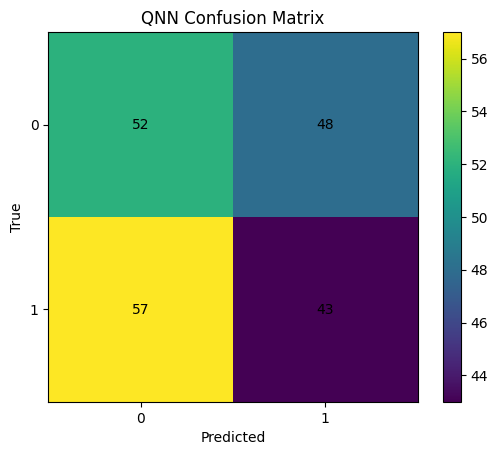

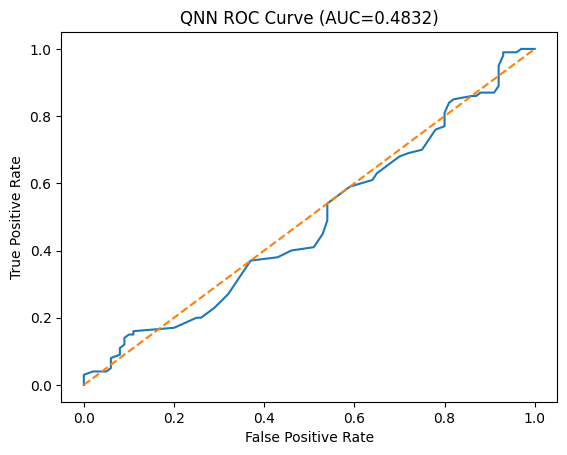

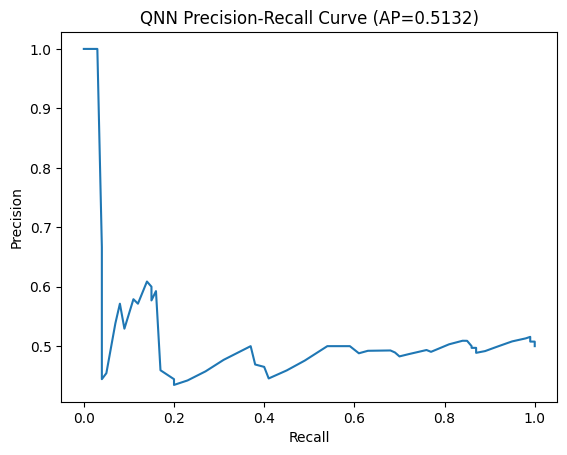

In [3]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)

from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_algorithms.optimizers import COBYLA

from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier

# ✅ Aer SamplerV2 (correct for qiskit-aer 0.17.2)
from qiskit_aer.primitives import SamplerV2 as AerSampler


# ----------------------------
# Load data
# ----------------------------
TRAIN_PATH = "train_pca12.csv"
TEST_PATH  = "test_pca12.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

def detect_label_col(df):
    candidates = ["label", "Label", "y", "Y", "target", "Target", "class", "Class"]
    for c in candidates:
        if c in df.columns:
            return c
    last = df.columns[-1]
    if df[last].nunique() <= 10:
        return last
    raise ValueError("Could not detect label column. Rename label column to 'label'.")

LABEL_COL = detect_label_col(train_df)
print("Detected LABEL_COL:", LABEL_COL)

X_train = train_df.drop(columns=[LABEL_COL]).values.astype(float)
y_train = train_df[LABEL_COL].values
X_test  = test_df.drop(columns=[LABEL_COL]).values.astype(float)
y_test  = test_df[LABEL_COL].values

def make_binary_01(y):
    y = np.array(y)
    uniq = np.unique(y)
    if set(uniq.tolist()) <= {0, 1}:
        return y.astype(int)
    if len(uniq) == 2:
        m = {uniq[0]: 0, uniq[1]: 1}
        return np.array([m[v] for v in y], dtype=int)
    raise ValueError(f"Labels are not binary. Unique labels: {uniq}")

y_train = make_binary_01(y_train)
y_test  = make_binary_01(y_test)

print("y_train distribution:", np.bincount(y_train))
print("y_test  distribution :", np.bincount(y_test))

# ----------------------------
# Scale
# ----------------------------
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

n_features = X_train_s.shape[1]
print("n_features (qubits):", n_features)

# ----------------------------
# Build QNN circuit = FeatureMap(x) + Ansatz(θ) + Measurements
# IMPORTANT: decompose() avoids Aer 'unknown instruction' errors
# ----------------------------
feature_map = ZZFeatureMap(feature_dimension=n_features, reps=1, entanglement="linear").decompose()
ansatz      = RealAmplitudes(num_qubits=n_features, reps=1, entanglement="linear").decompose()

qc = QuantumCircuit(n_features)
qc.compose(feature_map, inplace=True)
qc.compose(ansatz, inplace=True)
qc.measure_all()

# Input parameters (x) and trainable parameters (θ)
input_params  = list(feature_map.parameters)
weight_params = list(ansatz.parameters)

print("Input params :", len(input_params))
print("Weight params:", len(weight_params))
print("Circuit depth:", qc.depth(), " | size:", qc.size())

# ----------------------------
# Interpret bitstring -> class
# Parity mapping: even parity => 0, odd parity => 1
# ----------------------------
def parity(bitstring_as_int: int) -> int:
    return bin(bitstring_as_int).count("1") % 2

output_shape = 2

# ----------------------------
# Sampler setup (✅ correct)
# ----------------------------
sampler = AerSampler(default_shots=1024)   # ✅ correct in your version
print("Using AerSamplerV2 with default_shots=1024")

# ----------------------------
# Build SamplerQNN
# ----------------------------
qnn = SamplerQNN(
    circuit=qc,
    input_params=input_params,
    weight_params=weight_params,
    interpret=parity,
    output_shape=output_shape,
    sampler=sampler
)

# ----------------------------
# Train classifier on QNN
# ----------------------------
optimizer = COBYLA(maxiter=60)  # reduce for speed; increase to 80/120 if needed

loss_history = []
def callback(weights, loss):
    loss_history.append(loss)

clf = NeuralNetworkClassifier(
    neural_network=qnn,
    optimizer=optimizer,
    callback=callback
)

print("\nTraining QNN...")
clf.fit(X_train_s, y_train)
print("Training done.")

# ----------------------------
# Predict
# ----------------------------
y_pred = clf.predict(X_test_s)

y_proba = None
if hasattr(clf, "predict_proba"):
    try:
        y_proba = clf.predict_proba(X_test_s)[:, 1]
    except Exception:
        y_proba = None

# ----------------------------
# Metrics
# ----------------------------
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)

roc_auc = np.nan
pr_auc  = np.nan
if y_proba is not None and len(np.unique(y_test)) == 2:
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc  = average_precision_score(y_test, y_proba)

print("\n================ QNN RESULTS ================")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}" if not np.isnan(roc_auc) else "ROC-AUC  : (probabilities not available)")
print(f"PR-AUC   : {pr_auc:.4f}"  if not np.isnan(pr_auc)  else "PR-AUC   : (probabilities not available)")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# ----------------------------
# Plots
# ----------------------------
if len(loss_history) > 0:
    plt.figure()
    plt.plot(loss_history)
    plt.title("QNN Training Loss vs Iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.show()

plt.figure()
plt.imshow(cm, interpolation="nearest")
plt.title("QNN Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ["0","1"])
plt.yticks([0,1], ["0","1"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

if y_proba is not None and len(np.unique(y_test)) == 2:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0,1], [0,1], linestyle="--")
    plt.title(f"QNN ROC Curve (AUC={roc_auc:.4f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()

    pr, rc, _ = precision_recall_curve(y_test, y_proba)
    plt.figure()
    plt.plot(rc, pr)
    plt.title(f"QNN Precision-Recall Curve (AP={pr_auc:.4f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()